In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import gc

def calcular_matrices_fft(tiempo_array, señales_emg, intervalos_actividad, restimulus, frecuencia_muestreo, movimientos_interes):
    matrices_fft = []
    ventana_muestras = 200
    solapamiento = 100

    for inicio, fin in intervalos_actividad:
        idx_inicio = np.argmax(tiempo_array >= inicio)
        idx_fin = np.argmax(tiempo_array >= fin)

        if idx_inicio >= idx_fin:
            continue

        emg_segmentos = señales_emg[idx_inicio:idx_fin, :]
        mov_actual = restimulus[idx_inicio:idx_fin]
        movimientos_activos = mov_actual[np.isin(mov_actual, movimientos_interes)]

        if len(movimientos_activos) == 0:
            continue

        num_muestras = len(emg_segmentos)
        for i in range(0, num_muestras - ventana_muestras + 1, solapamiento):
            ventana_emg = emg_segmentos[i:i + ventana_muestras, :]
            mov_ventana = mov_actual[i:i + ventana_muestras]

            if len(np.unique(mov_ventana)) > 1:
                continue

            if len(ventana_emg) == ventana_muestras:
                fft_emg = np.abs(np.fft.fft(ventana_emg, axis=0))[:ventana_muestras // 2, :]
                mov = int(np.unique(mov_ventana)[0])
                matrices_fft.append([mov, fft_emg])

    return matrices_fft

def procesar_y_guardar_imagenes(base_path, output_base_path, num_sujetos, experimento, canales, movimientos_interes):
    for sujeto in range(1, num_sujetos + 1):
        folder_name = f's{sujeto}'
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.exists(folder_path):
            print(f'La ruta {folder_path} no existe.')
            continue

        exp_file = f'S{sujeto}_{experimento}_A1.mat'
        mat_path = os.path.join(folder_path, exp_file)

        if not os.path.exists(mat_path):
            print(f'El archivo {exp_file} no existe en la carpeta {folder_name}.')
            continue

        archivo_mat = loadmat(mat_path)
        señales_emg = archivo_mat['emg']
        restimulus = archivo_mat['restimulus'].flatten()
        frecuencia_muestreo = archivo_mat['frequency'][0, 0]
        num_muestras = señales_emg.shape[0]
        tiempo_array = np.arange(0, num_muestras) / frecuencia_muestreo

        actividad = restimulus > 0
        cambios = np.diff(actividad.astype(int))

        inicio_indices = np.where(cambios == 1)[0] + 1
        fin_indices = np.where(cambios == -1)[0] + 1

        if actividad[0]:
            inicio_indices = np.insert(inicio_indices, 0, 0)
        if actividad[-1]:
            fin_indices = np.append(fin_indices, len(actividad))

        if len(inicio_indices) == 0 or len(fin_indices) == 0:
            print(f'No se encontraron intervalos de actividad en el archivo {exp_file}.')
            continue

        intervalos_actividad = list(zip(inicio_indices / frecuencia_muestreo, fin_indices / frecuencia_muestreo))

        señales_emg_deseadas = señales_emg[:, [canal - 1 for canal in canales]]
        matrices_fft = calcular_matrices_fft(tiempo_array, señales_emg_deseadas, intervalos_actividad, restimulus, frecuencia_muestreo, movimientos_interes)

        for idx, (mov, matriz) in enumerate(matrices_fft):
            output_folder = os.path.join(output_base_path, f'Movimiento_{mov}')
            if not os.path.exists(output_folder):
                os.makedirs(output_folder)

            filename = f'sujeto_{sujeto}_ventana_{idx+1}.png'
            filepath = os.path.join(output_folder, filename)

            # Normalizar y guardar imagen
            fig, ax = plt.subplots()
            ax.imshow(matriz.T, cmap='gray', aspect='auto')
            ax.axis('off')
            plt.savefig(filepath, bbox_inches='tight', pad_inches=0)
            plt.close(fig)

            gc.collect()

        print(f'Sujeto {sujeto} procesado.')

# Ejemplo de uso
base_path = '/content/drive/My Drive/'  # Asegúrate de que esta sea la ruta correcta
output_base_path = '/content/drive/My Drive/PAPER/'  # Ruta para guardar las imágenes
num_sujetos = 10
experimento = 'E1'
canales = range(1, 9)
movimientos_interes = range(1, 13)

procesar_y_guardar_imagenes(base_path, output_base_path, num_sujetos, experimento, canales, movimientos_interes)

Sujeto 1 procesado.
Sujeto 2 procesado.
Sujeto 3 procesado.
Sujeto 4 procesado.
Sujeto 5 procesado.
Sujeto 6 procesado.
Sujeto 7 procesado.
Sujeto 8 procesado.
Sujeto 9 procesado.
Sujeto 10 procesado.


In [ ]:
import os
import shutil
import random

def create_train_val_test_split(base_path, output_base_path, test_ratio=0.3, val_ratio=0.2):
    movements = [f'Movimiento_{i}' for i in range(1, 13)]
    phases = ['Train', 'Validation', 'Test']

    for phase in phases:
        for movement in movements:
            os.makedirs(os.path.join(output_base_path, phase, movement), exist_ok=True)

    for movement in movements:
        movement_path = os.path.join(base_path, movement)
        images = os.listdir(movement_path)
        random.shuffle(images)

        num_images = len(images)
        num_test = int(num_images * test_ratio)
        num_val = int(num_images * (1 - test_ratio) * val_ratio)

        test_images = images[:num_test]
        val_images = images[num_test:num_test + num_val]
        train_images = images[num_test + num_val:]

        for img in test_images:
            shutil.copy(os.path.join(movement_path, img), os.path.join(output_base_path, 'Test', movement, img))

        for img in val_images:
            shutil.copy(os.path.join(movement_path, img), os.path.join(output_base_path, 'Validation', movement, img))

        for img in train_images:
            shutil.copy(os.path.join(movement_path, img), os.path.join(output_base_path, 'Train', movement, img))

# Ejemplo de uso
base_path = '/content/drive/My Drive/PAPER/'
output_base_path = '/content/drive/My Drive/PAPER/'
create_train_val_test_split(base_path, output_base_path)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import os

# Rutas a tus carpetas de entrenamiento, validación y prueba
train_dir = '/content/drive/My Drive/PAPER/Train'
val_dir = '/content/drive/My Drive/PAPER/Validation'
test_dir = '/content/drive/My Drive/PAPER/Test'

In [ ]:
# Generadores de datos de imágenes
train_datagen = ImageDataGenerator(rescale=1.0/255.0)
val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Flujos de datos de imágenes
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(250, 250),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(250, 250),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(250, 250),
    batch_size=32,
    class_mode='categorical'
)

Found 2508 images belonging to 12 classes.
Found 619 images belonging to 12 classes.
Found 1331 images belonging to 12 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(250, 250, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(12, activation='softmax')  # 12 clases para 12 movimientos
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=25
)

Epoch 1/25
78/78 [==============================] - 477s 6s/step - loss: 2.2279 - accuracy: 0.2072 - val_loss: 1.9510 - val_accuracy: 0.3470
Epoch 2/25
78/78 [==============================] - 426s 5s/step - loss: 1.8871 - accuracy: 0.3457 - val_loss: 1.7492 - val_accuracy: 0.4112
Epoch 3/25
78/78 [==============================] - 426s 5s/step - loss: 1.7131 - accuracy: 0.4019 - val_loss: 1.6311 - val_accuracy: 0.4572
Epoch 4/25
78/78 [==============================] - 440s 6s/step - loss: 1.5397 - accuracy: 0.4632 - val_loss: 1.4921 - val_accuracy: 0.4951
Epoch 5/25
78/78 [==============================] - 422s 5s/step - loss: 1.3784 - accuracy: 0.5194 - val_loss: 1.4018 - val_accuracy: 0.5230
Epoch 6/25
78/78 [==============================] - 426s 5s/step - loss: 1.1399 - accuracy: 0.6220 - val_loss: 1.3420 - val_accuracy: 0.5280
Epoch 7/25
78/78 [==============================] - 437s 6s/step - loss: 0.9680 - accuracy: 0.6628 - val_loss: 1.3465 - val_accuracy: 0.5345
Epoch 8/25
78

In [ ]:
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f'Test accuracy: {accuracy:.2f}')

# Guardar el modelo
model.save('/content/drive/My Drive/PAPER/modelo_movimientos.h5')

41/41 [==============================] - 57s 1s/step - loss: 1.9211 - accuracy: 0.5930
Test accuracy: 0.59


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


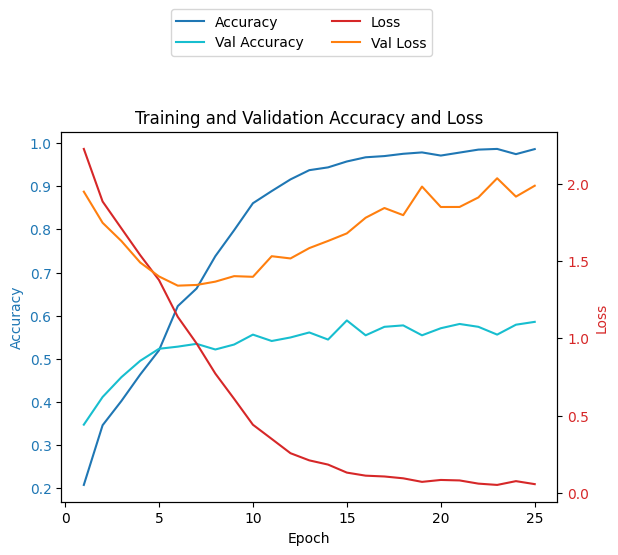

In [ ]:
import matplotlib.pyplot as plt

# Data
epochs = list(range(1, 26))
accuracy = [0.2072, 0.3457, 0.4019, 0.4632, 0.5194, 0.6220, 0.6628, 0.7379, 0.7981, 0.8607,
            0.8889, 0.9160, 0.9374, 0.9439, 0.9576, 0.9673, 0.9701, 0.9754, 0.9786, 0.9713,
            0.9782, 0.9851, 0.9867, 0.9746, 0.9863]
val_accuracy = [0.3470, 0.4112, 0.4572, 0.4951, 0.5230, 0.5280, 0.5345, 0.5214, 0.5329, 0.5559,
                0.5411, 0.5493, 0.5609, 0.5444, 0.5888, 0.5543, 0.5740, 0.5773, 0.5543, 0.5707,
                0.5806, 0.5740, 0.5559, 0.5789, 0.5855]
loss = [2.2279, 1.8871, 1.7131, 1.5397, 1.3784, 1.1399, 0.9680, 0.7722, 0.6087, 0.4409,
        0.3489, 0.2564, 0.2100, 0.1826, 0.1307, 0.1109, 0.1056, 0.0937, 0.0707, 0.0831,
        0.0800, 0.0593, 0.0509, 0.0754, 0.0560]
val_loss = [1.9510, 1.7492, 1.6311, 1.4921, 1.4018, 1.3420, 1.3465, 1.3680, 1.4036, 1.3993,
            1.5327, 1.5183, 1.5853, 1.6317, 1.6807, 1.7820, 1.8451, 1.7988, 1.9840, 1.8516,
            1.8519, 1.9135, 2.0378, 1.9189, 1.9894]

fig, ax1 = plt.subplots()

# Plot accuracy on primary y-axis
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy', color='tab:blue')
ax1.plot(epochs, accuracy, label='Accuracy', color='tab:blue')
ax1.plot(epochs, val_accuracy, label='Val Accuracy', color='tab:cyan')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create secondary y-axis for loss
ax2 = ax1.twinx()
ax2.set_ylabel('Loss', color='tab:red')
ax2.plot(epochs, loss, label='Loss', color='tab:red')
ax2.plot(epochs, val_loss, label='Val Loss', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Add legends
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

# Title and show plot
plt.title('Training and Validation Accuracy and Loss')
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/ste

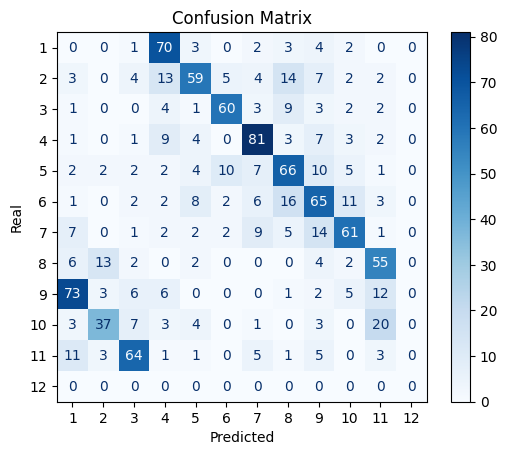

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ruta a la carpeta de test
test_dir = '/content/drive/My Drive/PAPER/Test'

# Cargar el modelo entrenado
model = tf.keras.models.load_model('/content/drive/My Drive/PAPER/modelo_movimientos.h5')

# Obtener una lista de todas las carpetas de movimientos en la carpeta de prueba
movements = os.listdir(test_dir)
movement_labels = {movement: index for index, movement in enumerate(movements)}

# Inicializar listas para etiquetas verdaderas y predichas
y_true = []
y_pred = []

# Iterar sobre cada carpeta de movimiento
for movement in movements:
    movement_path = os.path.join(test_dir, movement)

    # Iterar sobre cada imagen en la carpeta de movimiento
    for image_name in os.listdir(movement_path):
        image_path = os.path.join(movement_path, image_name)

        # Cargar y preprocesar la imagen
        img = image.load_img(image_path, target_size=(250, 250))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0  # Escalar los valores de la imagen

        # Hacer una predicción
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions[0])

        # Agregar las etiquetas verdadera y predicha a las listas
        y_true.append(movement_labels[movement])
        y_pred.append(predicted_class_index)

# Convertir y_true y y_pred a arrays de numpy para mayor compatibilidad
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Crear la matriz de confusión original
cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,5,6,7,8,9,10,11,12])



# Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4,5,6,7,8,9,10,11,12])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.savefig('matriz_confusion.png')  # Guardar la matriz de confusión como una imagen
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os
import random

# Ruta a la carpeta de test
test_dir = '/content/drive/My Drive/PAPER/Test'

# Cargar el modelo entrenado
model = tf.keras.models.load_model('/content/drive/My Drive/PAPER/modelo_movimientos.h5')

# Obtener una lista de todas las carpetas de movimientos en la carpeta de prueba
movements = os.listdir(test_dir)

# Elegir un movimiento y una imagen al azar de ese movimiento
random_movement = random.choice(movements)
movement_path = os.path.join(test_dir, random_movement)
random_image_name = random.choice(os.listdir(movement_path))
random_image_path = os.path.join(movement_path, random_image_name)

# Cargar y preprocesar la imagen
img = image.load_img(random_image_path, target_size=(250, 250))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # Escalar los valores de la imagen

# Hacer una predicción
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])
predicted_class = movements[predicted_class_index]

# Imprimir los resultados
print(f'Imagen seleccionada: {random_image_name}')
print(f'Movimiento real: {random_movement}')
print(f'Movimiento predicho por la IA: {predicted_class}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Imagen seleccionada: sujeto_3_ventana_24.png
Movimiento real: Movimiento_1
Movimiento predicho por la IA: Movimiento_1
